In [27]:
from sklearn.metrics import accuracy_score

In [2]:
import pandas as pd

df = pd.read_csv('iris.csv')
df.head(1)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa


In [4]:
df['Species'].unique()

<ArrowStringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

In [7]:
df = df.drop(['Id'],axis = 1)

In [9]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [14]:
X = df.iloc[:, 0:4]
y = df.iloc[:,-1]

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [18]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(120, 4)
(30, 4)
(120,)
(30,)


In [20]:
from sklearn.tree import DecisionTreeClassifier

In [21]:
DecisionTreeClassifier?

Init signature:
DecisionTreeClassifier(
    *,
    criterion='gini',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=None,
    random_state=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    class_weight=None,
    ccp_alpha=0.0,
    monotonic_cst=None,
)
Docstring:     
A decision tree classifier.

Read more in the :ref:`User Guide <tree>`.

Parameters
----------
criterion : {"gini", "entropy", "log_loss"}, default="gini"
    The function to measure the quality of a split. Supported criteria are
    "gini" for the Gini impurity and "log_loss" and "entropy" both for the
    Shannon information gain, see :ref:`tree_mathematical_formulation`.

splitter : {"best", "random"}, default="best"
    The strategy used to choose the split at each node. Supported
    strategies are "best" to choose the best split and "random" to choose
    the best random split.

max_depth : int, default=None

In [31]:
clf = DecisionTreeClassifier(criterion='gini',min_samples_split=4)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.9333333333333333


In [40]:
clf1 = DecisionTreeClassifier(criterion='entropy',min_samples_split=5)
clf1.fit(X_train,y_train)
y_pred = clf1.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.9666666666666667


In [52]:
clf1 = DecisionTreeClassifier(criterion='gini',min_samples_split=3,splitter='random')
clf1.fit(X_train,y_train)
y_pred = clf1.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.9666666666666667


In [81]:
data = pd.read_csv("titanic.csv")
data.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
pd.crosstab(data['Sex'], data['Survived'])

Survived,0,1
Sex,,
female,81,233
male,468,109


<Axes: xlabel='Sex', ylabel='count'>

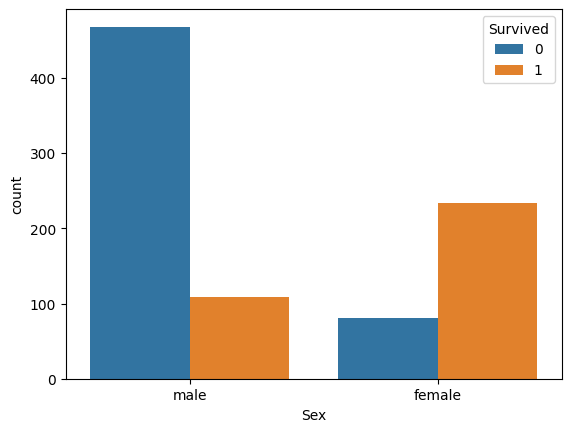

In [84]:
sns.countplot(x='Sex', hue='Survived', data=data)

In [85]:
data = data[['Sex','Age','Embarked','Survived']]

In [86]:
data.head(1)

,Sex,Age,Embarked,Survived
0,male,22.0,S,0


In [87]:
data['Embarked'].unique()

<ArrowStringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [88]:
data['Embarked'].isnull().sum()

np.int64(2)

In [89]:
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

C:\Users\krati\AppData\Local\Temp\ipykernel_29388\4247733614.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)


0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

In [91]:
from sklearn.preprocessing import LabelEncoder

In [92]:
encoder = LabelEncoder()

In [99]:
data['Sex'] = encoder.fit_transform(data['Sex'])

In [100]:
data['Embarked'] = encoder.fit_transform(data['Embarked'])

In [101]:
data.head()

,Sex,Age,Embarked,Survived
0,1,22.0,2,0
1,0,38.0,0,1
2,0,26.0,2,1
3,0,35.0,2,1
4,1,35.0,2,0


In [105]:
X1 = data.iloc[:,0:3]
y1 = data.iloc[:,-1]

In [107]:
X_train,X_test,y_train,y_test = train_test_split(X1,y1,test_size=0.2,random_state=2)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 3)
(179, 3)
(712,)
(179,)


In [115]:
model = DecisionTreeClassifier()
model.fit(X_train,y_train)
titanic_pred = model.predict(X_test)
print(accuracy_score(y_test,titanic_pred))

0.7486033519553073


In [121]:
model = DecisionTreeClassifier(criterion='entropy',max_depth=7,)
model.fit(X_train,y_train)
titanic_pred = model.predict(X_test)
print(accuracy_score(y_test,titanic_pred))

0.776536312849162


In [127]:
#DecisionTreeRegressor outputs numbers, not class labels.
from sklearn.tree import DecisionTreeRegressor

In [126]:
model = DecisionTreeRegressor(max_depth=5)
model.fit(X_train,y_train)
titanic_pred = model.predict(X_test)
print(accuracy_score(y_test,titanic_pred))

ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [143]:
from sklearn.metrics import mean_squared_error, r2_score

In [144]:
data = data.dropna(subset=['Age'])
X = data[['Sex', 'Embarked', 'Survived']]
y = data['Age']

In [145]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [149]:
model = DecisionTreeRegressor(criterion='friedman_mse',random_state=42)
model.fit(X_train, y_train)
age_pred = model.predict(X_test)
# print(accuracy_score(y_test,age_pred)) #  only for classification
print("MSE:", mean_squared_error(y_test, age_pred))
print("R2 Score:", r2_score(y_test, age_pred))

MSE: 189.88378816041765
R2 Score: -0.024161197261061806


## bhot ganda result aaya hai 
### lekin ye sirf DecisionTreeRegressor samajhne ke liye tha